<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 08: El Modelo Generativo de Series de Tiempo
## Seccion 5 del paper: Latent ODE como autoencoder variacional

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Explicar** el modelo generativo de la Seccion 5: $p(\mathbf{z}_{t_0})$, ODESolve, $p(\mathbf{x}|\mathbf{z})$
2. **Implementar** el encoder RNN que corre hacia atras y produce $\mu$ y $\sigma$
3. **Aplicar** el truco de reparametrizacion para muestrear $\mathbf{z}_{t_0}$
4. **Implementar** el ELBO como funcion de perdida: reconstruccion $-$ KL
5. **Visualizar** reconstrucciones y extrapolaciones en datos de espirales

---

> Las celdas **[OK]** estan listas con `Shift+Enter`. Las **[Ejercicio]** son para completar.


## 1. El modelo de la Seccion 5: ¿que problema resuelve?

Los modelos anteriores (NB05, NB06) tomaban una observacion completa y la clasificaban.
La Seccion 5 ataca un problema mucho mas rico: **series de tiempo con muestras irregulares**.

**Ejemplo medico:** un paciente tiene mediciones de glucosa a las 8am, 11am, 3pm y 9pm.
Otro paciente tiene mediciones a las 7am, 2pm y 8pm. Los tiempos son distintos para cada uno.
¿Como aprender un modelo que funcione para ambos y que pueda predecir en tiempos no observados?

La respuesta del paper es el **Latent ODE**: un modelo generativo continuo en el tiempo.

### El modelo generativo (ecuaciones 11-13 del paper)

$$\mathbf{z}_{t_0} \sim p(\mathbf{z}_{t_0}) = \mathcal{N}(\mathbf{0}, I) \tag{11}$$

$$\mathbf{z}_{t_1}, \mathbf{z}_{t_2}, \ldots, \mathbf{z}_{t_N} = \text{ODESolve}(\mathbf{z}_{t_0},\, f,\, \theta_f,\, t_0, \ldots, t_N) \tag{12}$$

$$\text{cada} \quad \mathbf{x}_{t_i} \sim p(\mathbf{x}\,|\,\mathbf{z}_{t_i},\, \theta_\mathbf{x}) \tag{13}$$

| Componente | Rol | Implementacion |
|-----------|-----|----------------|
| $p(\mathbf{z}_{t_0})$ | Prior gaussiano sobre el estado inicial | $\mathcal{N}(\mathbf{0}, I)$ -- no tiene parametros |
| ODESolve | Propaga $\mathbf{z}_{t_0}$ a todos los tiempos | RK4 con $f_\theta$ |
| $p(\mathbf{x}|\mathbf{z}, \theta_\mathbf{x})$ | Decoder: estado latente -> observacion | Red neuronal |
| $q_\phi(\mathbf{z}_0 | \mathbf{x}_1,...,\mathbf{x}_N)$ | Encoder: observaciones -> estado inicial | RNN inverso |


## 2. El truco de reparametrizacion: como entrenar con muestras

El encoder produce $\mu$ y $\sigma$ (media y desviacion estandar del estado inicial).
Para entrenar necesitamos el gradiente de la perdida respecto a esos parametros.
El problema: **no se puede backpropagar a traves de una operacion de muestreo**.

La solucion es el **truco de reparametrizacion**. En vez de muestrear:

$$\mathbf{z}_{t_0} \sim \mathcal{N}(\mu, \sigma^2)$$

Escribimos el muestreo como una transformacion determinista de ruido externo:

$$\mathbf{z}_{t_0} = \mu + \sigma \cdot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(\mathbf{0}, I)$$

Ahora $\mu$ y $\sigma$ son parametros del grafo computacional y el gradiente fluye a traves de ellos.
El ruido $\varepsilon$ viene de afuera -- es solo un numero aleatorio fijo durante el backward pass.

```
SIN truco (no funciona):                CON truco (funciona):

  mu, sigma                               mu, sigma
     |                                      |      |
  [MUESTREO]  <- no diferenciable        mu + sigma * epsilon
     |                                      |         ^
   z_t0                                  z_t0      epsilon ~ N(0,I)
     |                                      |         (viene de afuera)
  [perdida]                             [perdida]
  gradiente X                           gradiente OK
```


In [ ]:
# [OK] Imports

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
import tensorflow as tf
from tensorflow import keras

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.grid": True, "grid.alpha": 0.3,
})

VERDE = "#00843D"; AZUL = "#1a5fa8"; ROJO = "#c0392b"
NARANJA = "#e67e22"; MORADO = "#8e44ad"; GRIS = "#7f8c8d"

tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow", tf.__version__)


TensorFlow 2.20.0


## 3. Dataset: espirales bidireccionales (Seccion 5.1 del paper)

El paper usa **1000 espirales 2D**, mitad en sentido horario y mitad antihorario,
muestreadas en 100 puntos de tiempo igualmente espaciados con ruido gaussiano.

Cada espiral es una trayectoria en el espacio $(x_1, x_2)$ indexada por el tiempo $t$.
El estado latente $\mathbf{z}(t)$ vive en un espacio de **4 dimensiones** -- mas rico que
el espacio de observacion de 2 dimensiones, lo que permite al modelo capturar
la direccion de rotacion como una propiedad del estado latente.


In [ ]:
# [OK] Generar el dataset de espirales bidireccionales

def generar_espirales_dataset(n_traj=1000, n_puntos=100, ruido=0.3, seed=42):
    """
    Genera n_traj espirales en [0, 2*pi], mitad horario mitad antihorario.
    Retorna:
      data:  (n_traj, n_puntos, 2)  -- trayectorias
      times: (n_puntos,)            -- tiempos t_0...t_{n-1}
      labels:(n_traj,)              -- 0=antihorario, 1=horario
    """
    rng = np.random.default_rng(seed)
    T   = np.linspace(0, 6*np.pi, n_puntos)   # tiempos
    data, labels = [], []

    for i in range(n_traj):
        # amortiguamiento y velocidad angular aleatorios por trayectoria
        a = rng.uniform(0.8, 1.5)
        b = rng.uniform(0.3, 0.5)
        sentido = rng.choice([-1, 1])  # -1=antihorario, 1=horario
        x1 = a * np.exp(-b*T) * np.cos(sentido * T)
        x2 = a * np.exp(-b*T) * np.sin(sentido * T)
        traj = np.stack([x1, x2], axis=1)
        traj += rng.normal(0, ruido, traj.shape)
        data.append(traj)
        labels.append(0 if sentido == -1 else 1)

    data = np.array(data, dtype="float32")     # (n_traj, n_puntos, 2)
    labels = np.array(labels)                   # (n_traj,)
    return data, T.astype("float32"), labels


data, times, labels = generar_espirales_dataset(n_traj=1000, n_puntos=100, ruido=0.2)

print(f"Dataset generado:")
print(f"  data:   {data.shape}   <- (trayectorias, pasos, dimensiones)")
print(f"  times:  {times.shape}  <- tiempos de observacion")
print(f"  labels: {labels.shape} <- 0=antihorario, 1=horario")
print(f"  Antihorarias: {(labels==0).sum()}  |  Horarias: {(labels==1).sum()}")


Dataset generado:
  data:   (1000, 100, 2)   <- (trayectorias, pasos, dimensiones)
  times:  (100,)  <- tiempos de observacion
  labels: (1000,) <- 0=antihorario, 1=horario
  Antihorarias: 495  |  Horarias: 505


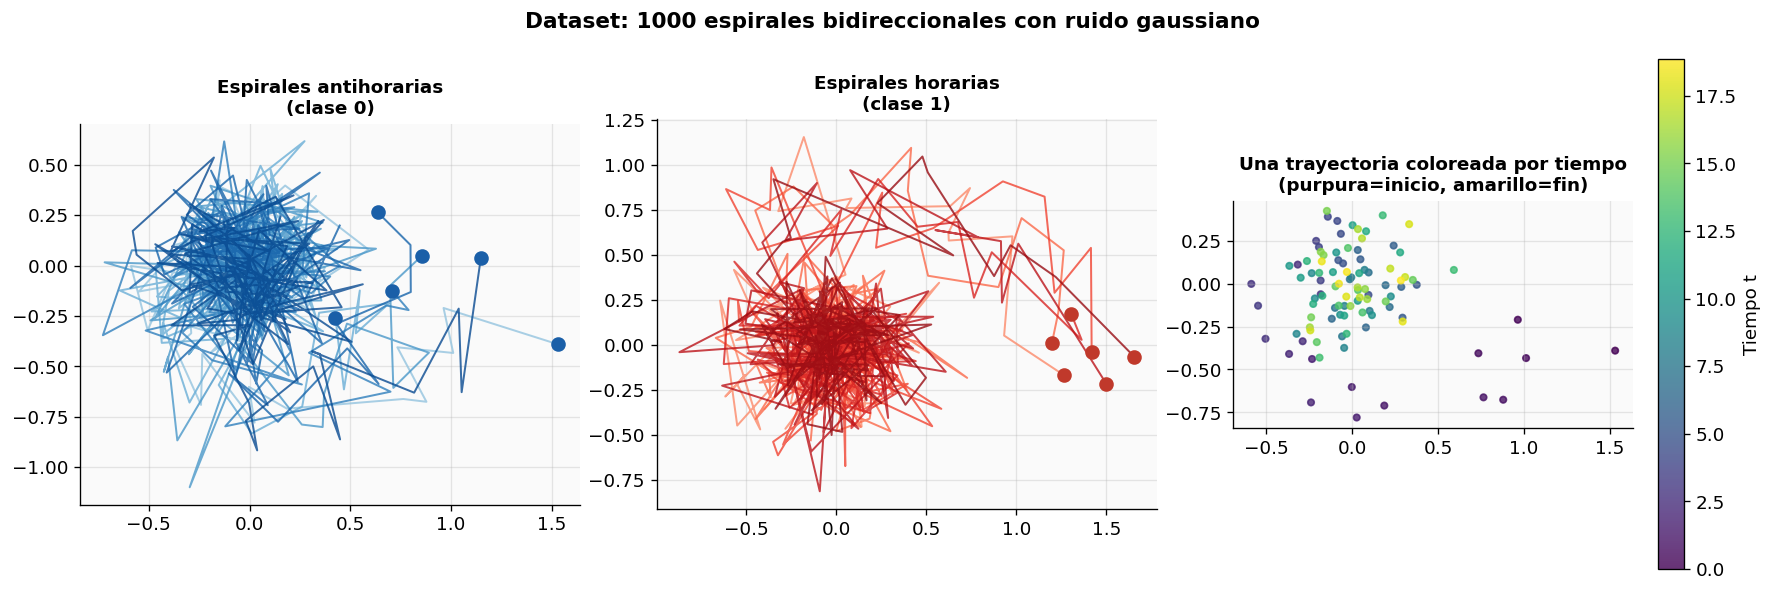

Desafio: el modelo debe aprender a:
  1. Reconstruir la trayectoria vista (interpolacion)
  2. Predecir mas alla del ultimo punto observado (extrapolacion)
  3. Funcionar aunque los tiempos de observacion sean irregulares


In [ ]:
# [OK] Visualizar el dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: ejemplos antihorarios
idx0 = np.where(labels == 0)[0][:6]
for i, idx in enumerate(idx0):
    traj = data[idx]
    axes[0].plot(traj[:,0], traj[:,1],
                 color=cm.Blues(0.4 + i*0.1), linewidth=1.2, alpha=0.8)
    axes[0].scatter(traj[0,0], traj[0,1], s=60, color=AZUL, zorder=5)
axes[0].set_title("Espirales antihorarias\n(clase 0)", fontsize=11, fontweight="bold")
axes[0].set_aspect("equal")

# Panel 2: ejemplos horarios
idx1 = np.where(labels == 1)[0][:6]
for i, idx in enumerate(idx1):
    traj = data[idx]
    axes[1].plot(traj[:,0], traj[:,1],
                 color=cm.Reds(0.4 + i*0.1), linewidth=1.2, alpha=0.8)
    axes[1].scatter(traj[0,0], traj[0,1], s=60, color=ROJO, zorder=5)
axes[1].set_title("Espirales horarias\n(clase 1)", fontsize=11, fontweight="bold")
axes[1].set_aspect("equal")

# Panel 3: secuencia temporal de una trayectoria
traj_ej = data[0]
sc = axes[2].scatter(traj_ej[:,0], traj_ej[:,1],
                      c=times, cmap="viridis", s=15, alpha=0.8)
plt.colorbar(sc, ax=axes[2], label="Tiempo t")
axes[2].set_title("Una trayectoria coloreada por tiempo\n(purpura=inicio, amarillo=fin)",
                   fontsize=11, fontweight="bold")
axes[2].set_aspect("equal")

plt.suptitle("Dataset: 1000 espirales bidireccionales con ruido gaussiano",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Desafio: el modelo debe aprender a:")
print("  1. Reconstruir la trayectoria vista (interpolacion)")
print("  2. Predecir mas alla del ultimo punto observado (extrapolacion)")
print("  3. Funcionar aunque los tiempos de observacion sean irregulares")


In [ ]:
# [OK] Preparar datos: split train/test y simular tiempos irregulares

N_TRAIN = 800
N_OBS   = 30    # puntos observados (de 100 totales)
DIM_OBS = 2     # dimensiones de la observacion
DIM_LAT = 4     # dimensiones del espacio latente (como en el paper)

X_train  = data[:N_TRAIN]        # (800, 100, 2)
X_test   = data[N_TRAIN:]        # (200, 100, 2)
lbl_train = labels[:N_TRAIN]
lbl_test  = labels[N_TRAIN:]

def submuestra_irregular(X, times, n_obs=30, seed=None):
    """
    Toma n_obs puntos aleatorios (sin reemplazo) de cada trayectoria.
    Simula el escenario de tiempos de observacion irregulares del paper.
    Retorna:
      X_sub:     (n_traj, n_obs, dim) -- observaciones subseleccionadas
      t_sub:     (n_obs,)             -- tiempos correspondientes
      idx_sorted: indices de tiempo seleccionados (ordenados)
    """
    rng = np.random.default_rng(seed)
    n_total = X.shape[1]
    idx = np.sort(rng.choice(n_total, n_obs, replace=False))
    return X[:, idx, :], times[idx], idx


X_obs, t_obs, idx_obs = submuestra_irregular(X_train, times, n_obs=N_OBS, seed=7)

print(f"Datos completos:     X_train {X_train.shape}")
print(f"Datos observados:    X_obs   {X_obs.shape}  <- solo {N_OBS} de 100 pasos")
print(f"Tiempos observados:  t_obs   {t_obs.shape}")
print(f"Tiempos observados (primeros 8): {t_obs[:8].round(2)}")
print()
print("En el escenario del paper, el modelo ve solo X_obs durante el entrenamiento.")
print("La evaluacion se hace sobre los 100 puntos -- incluyendo los no vistos.")


Datos completos:     X_train (800, 100, 2)
Datos observados:    X_obs   (800, 30, 2)  <- solo 30 de 100 pasos
Tiempos observados:  t_obs   (30,)
Tiempos observados (primeros 8): [0.   0.76 1.9  2.09 3.24 4.38 4.57 4.95]

En el escenario del paper, el modelo ve solo X_obs durante el entrenamiento.
La evaluacion se hace sobre los 100 puntos -- incluyendo los no vistos.


## 4. El Encoder: RNN que corre hacia atras

El encoder tiene que inferir el estado inicial $\mathbf{z}_{t_0}$ a partir
de todas las observaciones disponibles $\mathbf{x}_{t_1}, \ldots, \mathbf{x}_{t_N}$.

La idea clave del paper: **correr la RNN en orden inverso al tiempo**.
La ultima observacion $\mathbf{x}_{t_N}$ se procesa primero, y la primera $\mathbf{x}_{t_1}$ se procesa ultima.
Esto es porque lo que queremos al final es el estado inicial $\mathbf{z}_{t_0}$ --
y para estimarlo, es natural que la ultima actualizacion de la RNN sea con la observacion mas cercana a $t_0$.

La RNN produce dos vectores: $\mu$ y $\log\sigma$ (trabajamos con el logaritmo
para garantizar que $\sigma > 0$ sin restricciones en los pesos).

```
Observaciones en orden inverso:

  x_{tN} -> [RNN] -> h_{tN}
                         |
  x_{tN-1} -> [RNN] -> h_{tN-1}
                           |
              ...          ...
                               |
  x_{t1} -> [RNN] -> h_{t1} -> [Dense] -> mu, log_sigma
                                                |
                               z_t0 = mu + sigma * epsilon
```


In [ ]:
# [OK] Encoder RNN

class EncoderRNN(keras.layers.Layer):
    """
    Encoder: lee las observaciones en orden INVERSO y produce mu y log_sigma.
    Arquitectura del paper: GRU con 25 unidades ocultas.
    """
    def __init__(self, dim_latente, dim_oculto=25, **kwargs):
        super().__init__(**kwargs)
        self.gru = keras.layers.GRU(
            dim_oculto,
            return_sequences=False,  # solo el estado final
            go_backwards=True,       # <- leer en orden INVERSO (clave del paper)
        )
        # Capa que convierte el estado oculto en mu y log_sigma
        self.a_mu       = keras.layers.Dense(dim_latente)
        self.a_logsigma = keras.layers.Dense(dim_latente)

    def call(self, x, training=False):
        """
        x: (batch, n_obs, dim_obs) -- secuencia de observaciones
        Retorna: mu, log_sigma de forma (batch, dim_latente)
        """
        h = self.gru(x, training=training)   # (batch, dim_oculto)
        mu        = self.a_mu(h)              # (batch, dim_latente)
        log_sigma = self.a_logsigma(h)        # (batch, dim_latente)
        return mu, log_sigma


# Prueba
enc_test = EncoderRNN(dim_latente=DIM_LAT)
x_test   = tf.random.normal((4, N_OBS, DIM_OBS))
mu_t, ls_t = enc_test(x_test)
print(f"Entrada al encoder:  {x_test.shape}  <- (batch, n_obs, dim_obs)")
print(f"mu:                  {mu_t.shape}    <- (batch, dim_latente)")
print(f"log_sigma:           {ls_t.shape}    <- (batch, dim_latente)")
print("[OK] Encoder RNN funciona.")


Entrada al encoder:  (4, 30, 2)  <- (batch, n_obs, dim_obs)
mu:                  (4, 4)    <- (batch, dim_latente)
log_sigma:           (4, 4)    <- (batch, dim_latente)
[OK] Encoder RNN funciona.


In [ ]:
# [Ejercicio 1] El truco de reparametrizacion
#
# El encoder produce mu y log_sigma.
# Necesitamos muestrear z_t0 de forma que el gradiente pueda fluir
# hacia mu y log_sigma.
#
# Formula: z_t0 = mu + sigma * epsilon
#          donde sigma = exp(log_sigma)   (garantiza sigma > 0)
#          y epsilon ~ N(0, I)            (ruido externo)

def reparametrizar(mu, log_sigma):
    """
    Muestrea z_t0 usando el truco de reparametrizacion.

    mu:        (batch, dim_latente) -- media del encoder
    log_sigma: (batch, dim_latente) -- log desviacion estandar

    Retorna:
      z:       (batch, dim_latente) -- muestra de q_phi(z0 | x)
      sigma:   (batch, dim_latente) -- desviacion estandar
    """
    # ================================================
    # [Ejercicio] Completa el truco de reparametrizacion.
    # Paso 1: calcula sigma = exp(log_sigma)
    #         (tf.exp es la exponencial)
    # Paso 2: genera epsilon ~ N(0,I) con la misma forma que mu
    #         (tf.random.normal(tf.shape(mu)))
    # Paso 3: retorna mu + sigma * epsilon, sigma
    # ================================================
    sigma   = tf.exp(log_sigma)   # <- exp(log_sigma)
    epsilon = tf.random.normal(tf.shape(mu))   # <- ruido N(0,I) con forma igual a mu
    z       = mu + sigma * epsilon   # <- mu + sigma * epsilon
    return z, sigma


# Verificacion
mu_v  = tf.zeros((4, DIM_LAT))
ls_v  = tf.zeros((4, DIM_LAT))   # log_sigma=0 => sigma=1
z_v, sigma_v = reparametrizar(mu_v, ls_v)

if z_v is not None:
    print(f"mu:      {mu_v.shape}")
    print(f"sigma:   {sigma_v.shape}  <- debe ser exp(0) = 1.0")
    print(f"sigma[0,0]: {sigma_v[0,0]:.4f}  (esperado: 1.0)")
    print(f"z_t0:    {z_v.shape}  <- muestra = mu + sigma * epsilon")
    print()
    if abs(sigma_v[0,0].numpy() - 1.0) < 1e-4:
        print("[OK] Reparametrizacion correcta.")
    else:
        print("[!] Revisa: sigma deberia ser exp(0) = 1.0")
else:
    print("[!] Completa el ejercicio.")


mu:      (4, 4)
sigma:   (4, 4)  <- debe ser exp(0) = 1.0
sigma[0,0]: 1.0000  (esperado: 1.0)
z_t0:    (4, 4)  <- muestra = mu + sigma * epsilon

[OK] Reparametrizacion correcta.


In [ ]:
# [OK] La red de dinamica f_theta y el decoder

class RedDinamica(keras.layers.Layer):
    """f_theta: dz/dt = f_theta(z, t) -- igual que NB06 pero con dim_latente."""
    def __init__(self, dim_latente, dim_oculto=20, **kwargs):
        super().__init__(**kwargs)
        # Paper: una capa oculta con 20 unidades (dim_oculto=20)
        # Nota: recibe z concatenado con t -> dim_latente + 1 entradas
        self.net = keras.Sequential([
            keras.layers.Dense(dim_oculto, activation="tanh",
                               input_shape=(dim_latente + 1,)),
            keras.layers.Dense(dim_latente),
        ])

    def call(self, z, t):
        t_vec   = tf.ones((tf.shape(z)[0], 1)) * t
        entrada = tf.concat([z, t_vec], axis=-1)
        return self.net(entrada)


class Decoder(keras.layers.Layer):
    """
    Decoder: z_ti -> x_hat_ti
    Paper: una capa oculta con 20 unidades.
    """
    def __init__(self, dim_latente, dim_obs, dim_oculto=20, **kwargs):
        super().__init__(**kwargs)
        self.net = keras.Sequential([
            keras.layers.Dense(dim_oculto, activation="relu",
                               input_shape=(dim_latente,)),
            keras.layers.Dense(dim_obs),   # salida lineal: puede ser positivo o negativo
        ])

    def call(self, z):
        """
        z: (batch, n_pasos, dim_latente)  -- estados latentes en todos los tiempos
        Retorna: x_hat: (batch, n_pasos, dim_obs)
        """
        # TimeDistributed aplica el decoder independientemente a cada paso de tiempo
        batch_size  = tf.shape(z)[0]
        n_pasos     = tf.shape(z)[1]
        z_flat      = tf.reshape(z, (-1, z.shape[-1]))    # (batch*n_pasos, dim_lat)
        x_flat      = self.net(z_flat)                     # (batch*n_pasos, dim_obs)
        return tf.reshape(x_flat, (batch_size, n_pasos, -1)) # (batch, n_pasos, dim_obs)


# Prueba
din_test = RedDinamica(DIM_LAT, dim_oculto=20)
dec_test = Decoder(DIM_LAT, DIM_OBS, dim_oculto=20)
z_ej = tf.random.normal((4, DIM_LAT))
dz   = din_test(z_ej, t=0.5)
# decoder sobre secuencia
z_seq = tf.random.normal((4, N_OBS, DIM_LAT))
x_hat = dec_test(z_seq)
print(f"RedDinamica: z {z_ej.shape} -> dz/dt {dz.shape}")
print(f"Decoder: z_seq {z_seq.shape} -> x_hat {x_hat.shape}")
print("[OK] Dinamica y decoder listos.")


RedDinamica: z (4, 4) -> dz/dt (4, 4)
Decoder: z_seq (4, 30, 4) -> x_hat (4, 30, 2)
[OK] Dinamica y decoder listos.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# [OK] ODESolve para multiples tiempos de salida
#
# Diferencia con NB06: aqui necesitamos z en CADA tiempo de observacion,
# no solo en t=1. La solucion: dar pequenos pasos RK4 guardando el estado
# en cada tiempo de interes.

def odesolve_rk4_multistep(f, z0, times):
    """
    Integra dz/dt = f(z, t) y retorna z en cada tiempo de `times`.

    f:     RedDinamica
    z0:    (batch, dim_latente) -- estado inicial
    times: (n_tiempos,)        -- tiempos de salida, primer elemento = t inicial

    Retorna:
      Z:   (batch, n_tiempos, dim_latente) -- estados en cada tiempo
    """
    z_actual = z0
    trayectoria = [z0[:, tf.newaxis, :]]   # guardar z en t0

    for i in range(len(times) - 1):
        t0_paso = float(times[i])
        t1_paso = float(times[i+1])
        h       = t1_paso - t0_paso

        # Un paso de RK4 de t0_paso a t1_paso
        k1 = f(z_actual, t = t0_paso)
        k2 = f(z_actual + (h/2)*k1, t = t0_paso + h/2)
        k3 = f(z_actual + (h/2)*k2, t = t0_paso + h/2)
        k4 = f(z_actual + h*k3, t = t1_paso)
        z_actual = z_actual + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

        trayectoria.append(z_actual[:, tf.newaxis, :])

    return tf.concat(trayectoria, axis=1)  # (batch, n_tiempos, dim_latente)


# Prueba
z0_p  = tf.random.normal((3, DIM_LAT))
din_p = RedDinamica(DIM_LAT)
Z_p   = odesolve_rk4_multistep(din_p, z0_p, t_obs[:10])
print(f"z0:   {z0_p.shape}")
print(f"Z:    {Z_p.shape}  <- (batch, n_tiempos, dim_latente)")
print("[OK] ODESolve multistep funciona.")


z0:   (3, 4)
Z:    (3, 10, 4)  <- (batch, n_tiempos, dim_latente)
[OK] ODESolve multistep funciona.


## 5. La funcion de perdida: el ELBO

El modelo se entrena maximizando el **ELBO** (*Evidence Lower Bound*),
que en forma negativa (para minimizar) es:

$$\mathcal{L} = \underbrace{-\mathbb{E}_{q_\phi}\left[\log p(\mathbf{x} \,|\, \mathbf{z})\right]}_{\text{perdida de reconstruccion}} + \underbrace{D_{\text{KL}}\left(q_\phi(\mathbf{z}_0 \,|\, \mathbf{x}) \,\|\, p(\mathbf{z}_0)\right)}_{\text{termino de regularizacion}}$$

**Termino 1 -- Reconstruccion:** que tan bien reproduce el decoder las observaciones.
Usamos el error cuadratico medio (MSE) como aproximacion a $-\log p(\mathbf{x}|\mathbf{z})$
bajo una distribucion gaussiana con varianza fija.

**Termino 2 -- KL:** que tan lejos esta el posterior $q_\phi(\mathbf{z}_0|\mathbf{x})$
del prior $p(\mathbf{z}_0) = \mathcal{N}(\mathbf{0}, I)$.
Para dos gaussianas tiene formula cerrada:

$$D_{\text{KL}}\left(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0, 1)\right)
= \frac{1}{2}\sum_j \left(\sigma_j^2 + \mu_j^2 - 1 - \log \sigma_j^2\right)$$

> **Intuicion:** el termino KL actua como regularizador. Sin el, el encoder podria
> "colapsar" y mapear todas las observaciones al mismo $\mathbf{z}_0$, memorizando los datos
> sin aprender ninguna estructura generativa.


In [ ]:
# [Ejercicio 2] Implementar la funcion de perdida ELBO

def perdida_elbo(x_obs, x_hat, mu, sigma):
    """
    Calcula la perdida ELBO (negativa, para minimizar).

    x_obs:  (batch, n_obs, dim_obs) -- observaciones reales
    x_hat:  (batch, n_obs, dim_obs) -- reconstrucciones del decoder
    mu:     (batch, dim_latente)    -- media del encoder
    sigma:  (batch, dim_latente)    -- desviacion estandar del encoder

    Retorna: perdida escalar (promedio sobre el batch)
    """
    # ================================================
    # [Ejercicio] Implementa los dos terminos del ELBO.
    #
    # TERMINO 1: Reconstruccion
    #   Error cuadratico medio entre x_obs y x_hat.
    #   Usa tf.reduce_mean((x_obs - x_hat)**2)
    #   (promedio sobre batch, tiempo y dimensiones)
    #
    # TERMINO 2: KL divergence
    #   Formula cerrada para KL entre N(mu, sigma^2) y N(0, I):
    #   kl_por_dim = 0.5 * (sigma**2 + mu**2 - 1 - tf.math.log(sigma**2 + 1e-8))
    #   kl = tf.reduce_mean(tf.reduce_sum(kl_por_dim, axis=-1))
    #   (suma sobre dimensiones latentes, promedio sobre batch)
    #
    # ELBO = reconstruccion + kl
    # ================================================
    reconstruccion = tf.reduce_mean((x_obs - x_hat)**2)   # <- MSE entre x_obs y x_hat
    kl_por_dim = 0.5 * (sigma**2 + mu**2 - 1 - tf.math.log(sigma**2 + 1e-8))
    kl  = tf.reduce_mean(tf.reduce_sum(kl_por_dim, axis=-1))   # <- KL divergence
    return reconstruccion, kl, (reconstruccion + kl) if reconstruccion is not None else None


# Verificacion
x_o  = tf.random.normal((4, N_OBS, DIM_OBS))
x_h  = x_o + tf.random.normal((4, N_OBS, DIM_OBS)) * 0.1   # reconstruccion casi perfecta
mu_v = tf.zeros((4, DIM_LAT))
sg_v = tf.ones((4, DIM_LAT))   # sigma=1 -> KL con N(0,I) deberia ser ~0

rec, kl, total = perdida_elbo(x_o, x_h, mu_v, sg_v)

if rec is not None:
    print(f"Reconstruccion: {rec:.6f}  (pequeña: reconstruccion casi perfecta)")
    print(f"KL divergence:  {kl:.6f}  (debe ser ~0 cuando sigma=1, mu=0)")
    print(f"ELBO total:     {total:.6f}")
    print()
    if abs(kl.numpy()) < 0.01:
        print("[OK] ELBO implementado correctamente.")
    else:
        print("[!] Revisa el termino KL: deberia ser ~0 con mu=0 y sigma=1")
else:
    print("[!] Completa el ejercicio.")


Reconstruccion: 0.011207  (pequeña: reconstruccion casi perfecta)
KL divergence:  0.000000  (debe ser ~0 cuando sigma=1, mu=0)
ELBO total:     0.011207

[OK] ELBO implementado correctamente.


In [ ]:
# [OK] Ensamblar el modelo Latent ODE completo (Figura 6 del paper)

class LatentODE(keras.Model):
    """
    Modelo completo de la Seccion 5:

    ENCODER:  x_{t1},...,x_{tN} -> [RNN inverso] -> mu, log_sigma
              z_t0 = mu + sigma * epsilon  (reparametrizacion)

    ODESOLVE: dz/dt = f_theta(z, t), de t0 a t_M
              -> z_{t0}, z_{t1}, ..., z_{tM}

    DECODER:  z_{ti} -> x_hat_{ti}  para cada tiempo

    PERDIDA:  ELBO = reconstruccion + KL
    """
    def __init__(self, dim_obs, dim_latente, dim_oculto_rnn=25,
                 dim_oculto_f=20, dim_oculto_dec=20, **kwargs):
        super().__init__(**kwargs)
        self.encoder  = EncoderRNN(dim_latente, dim_oculto_rnn)
        self.dinamica = RedDinamica(dim_latente, dim_oculto_f)
        self.decoder  = Decoder(dim_latente, dim_obs, dim_oculto_dec)

    def call(self, x_obs, times, training=False):
        """
        x_obs: (batch, n_obs, dim_obs)  -- observaciones de entrada
        times: (n_obs,)                 -- tiempos de las observaciones

        Retorna: x_hat, mu, sigma, z_traj
        """
        # 1. Encoder: inferir el estado inicial
        mu, log_sigma = self.encoder(x_obs, training=training)

        # 2. Reparametrizacion: muestrear z_t0
        z0, sigma = reparametrizar(mu, log_sigma)

        # 3. ODESolve: propagar z_t0 a todos los tiempos
        Z_traj = odesolve_rk4_multistep(self.dinamica, z0, times)
        # Z_traj: (batch, n_tiempos, dim_latente)

        # 4. Decoder: reconstruir observaciones desde los estados latentes
        x_hat = self.decoder(Z_traj)
        # x_hat: (batch, n_tiempos, dim_obs)

        return x_hat, mu, sigma, Z_traj


# Construir y probar
tf.random.set_seed(42)
latent_ode = LatentODE(
    dim_obs=DIM_OBS, dim_latente=DIM_LAT,
    dim_oculto_rnn=25, dim_oculto_f=20, dim_oculto_dec=20
)

x_batch = tf.constant(X_obs[:4])
x_hat_p, mu_p, sigma_p, Z_p = latent_ode(x_batch, t_obs)

print(f"Entrada x_obs:    {x_batch.shape}")
print(f"Salida x_hat:     {x_hat_p.shape}  <- reconstruccion")
print(f"mu:               {mu_p.shape}")
print(f"sigma:            {sigma_p.shape}")
print(f"Z_traj:           {Z_p.shape}  <- trayectoria latente")
print()
latent_ode.summary()


Entrada x_obs:    (4, 30, 2)
Salida x_hat:     (4, 30, 2)  <- reconstruccion
mu:               (4, 4)
sigma:            (4, 4)
Z_traj:           (4, 30, 4)  <- trayectoria latente



Model: "latent_ode_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_rnn_4 (EncoderRNN)      │ ?                      │         2,383 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ red_dinamica_11 (RedDinamica)   │ ?                      │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_6 (Decoder)             │ ?                      │           142 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,729 (10.66 KB)

 Trainable params: 2,729 (10.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# [OK] Entrenamiento con gradient tape

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def paso_entrenamiento(x_batch, times):
    with tf.GradientTape() as tape:
        x_hat, mu, sigma, _ = latent_ode(x_batch, times, training=True)
        rec, kl, loss = perdida_elbo(x_batch, x_hat, mu, sigma)
    grads = tape.gradient(loss, latent_ode.trainable_variables)
    optimizer.apply_gradients(zip(grads, latent_ode.trainable_variables))
    return rec, kl, loss


N_EPOCHS  = 40
BATCH     = 64
n_batches = N_TRAIN // BATCH

hist_rec, hist_kl, hist_tot = [], [], []

print(f"Entrenando Latent ODE: {N_EPOCHS} epocas, batch={BATCH}...")
print(f"  Parametros: {latent_ode.count_params():,}")
print()

t0 = time.time()
for epoca in range(N_EPOCHS):
    # Shuffle
    idx_sh  = np.random.permutation(N_TRAIN)
    X_sh    = X_obs[idx_sh]

    rec_ep, kl_ep, tot_ep = 0.0, 0.0, 0.0
    for b in range(n_batches):
        x_b = tf.constant(X_sh[b*BATCH:(b+1)*BATCH])
        r, k, l = paso_entrenamiento(x_b, t_obs)
        rec_ep += r.numpy(); kl_ep += k.numpy(); tot_ep += l.numpy()

    rec_ep /= n_batches; kl_ep /= n_batches; tot_ep /= n_batches
    hist_rec.append(rec_ep); hist_kl.append(kl_ep); hist_tot.append(tot_ep)

    if (epoca+1) % 10 == 0:
        print(f"  Epoca {epoca+1:3d}/{N_EPOCHS}  "
              f"rec={rec_ep:.4f}  kl={kl_ep:.4f}  total={tot_ep:.4f}")

dt = time.time() - t0
print(f"\nEntrenamiento completado: {dt:.1f}s")


Entrenando Latent ODE: 40 epocas, batch=64...
  Parametros: 2,729



OperatorNotAllowedInGraphError: in user code:

    File "/tmp/ipykernel_57545/1678565529.py", line 8, in paso_entrenamiento  *
        x_hat, mu, sigma, _ = latent_ode(x_batch, times, training=True)
    File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/tmp/ipykernel_57545/2005248570.py", line 38, in call
        Z_traj = odesolve_rk4_multistep(self.dinamica, z0, times)
    File "/tmp/ipykernel_57545/2359690040.py", line 21, in odesolve_rk4_multistep
        for i in tf.range(tf.shape(times)[0] - 1):

    OperatorNotAllowedInGraphError: Exception encountered when calling LatentODE.call().
    
    [1mIterating over a symbolic `tf.Tensor` is not allowed. You can attempt the following resolutions to the problem: If you are running in Graph mode, use Eager execution mode or decorate this function with @tf.function. If you are using AutoGraph, you can try decorat

In [ ]:
# [OK] Curvas de aprendizaje

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, hist, titulo, color in [
    (axes[0], hist_rec, "Reconstruccion (MSE)",    AZUL),
    (axes[1], hist_kl,  "KL divergence",            NARANJA),
    (axes[2], hist_tot, "ELBO total (minimizar)",   ROJO),
]:
    ax.plot(range(1, N_EPOCHS+1), hist, color=color, linewidth=2)
    ax.set_xlabel("Epoca"); ax.set_ylabel("Perdida")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.fill_between(range(1, N_EPOCHS+1), hist, alpha=0.1, color=color)

plt.suptitle("Curvas de entrenamiento del Latent ODE", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Observa:")
print("  Reconstruccion baja -> el decoder aprende a reproducir las espirales")
print("  KL sube levemente -> el encoder usa el espacio latente (no colapsa a prior)")


In [ ]:
# [OK] Visualizar reconstrucciones: datos observados vs reconstruidos

def reconstruir_y_extrapolar(modelo, x_obs_batch, t_obs, times_full):
    """
    Reconstruye en t_obs (observados) y extrapola en times_full (todos los tiempos).
    """
    x_hat_obs,  mu, sigma, Z_obs  = modelo(tf.constant(x_obs_batch), t_obs)
    # Para extrapolar: usar el mismo z0 pero con todos los tiempos
    z0, _ = reparametrizar(mu, tf.math.log(sigma + 1e-8))
    Z_full = odesolve_rk4_multistep(modelo.dinamica, z0, times)
    x_hat_full = modelo.decoder(Z_full)
    return x_hat_obs.numpy(), x_hat_full.numpy(), Z_obs.numpy()


# Tomar ejemplos del test set
X_test_obs, _, _ = submuestra_irregular(X_test, times, n_obs=N_OBS, seed=99)

x_hat_obs, x_hat_full, Z_lat = reconstruir_y_extrapolar(
    latent_ode, X_test_obs[:6], t_obs, times)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    # Ground truth completo
    gt = X_test[i]
    ax.plot(gt[:,0], gt[:,1], color=GRIS, linewidth=1.5,
            alpha=0.5, label="Ground truth")

    # Puntos observados
    obs = X_test_obs[i]
    ax.scatter(obs[:,0], obs[:,1], s=25, color=AZUL, zorder=4,
               alpha=0.8, label=f"Observado ({N_OBS} pts)")

    # Reconstruccion en todos los tiempos
    xf = x_hat_full[i]
    ax.plot(xf[:,0], xf[:,1], color=ROJO, linewidth=2,
            linestyle="--", label="Prediccion Latent ODE", alpha=0.9)

    # Marcar inicio
    ax.scatter(gt[0,0], gt[0,1], s=100, color="black",
               zorder=6, marker="*", label="Inicio")

    ax.set_aspect("equal")
    ax.set_title(f"Trayectoria {i+1}", fontsize=10, fontweight="bold")
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Reconstruccion e interpolacion del Latent ODE\n"
             "(gris=ground truth, azul=observado, rojo=prediccion)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# [OK] Evaluacion: RMSE predictivo en tiempos no observados (Tabla 2 del paper)

def calcular_rmse(modelo, X_full, times, n_obs_list=[30, 50, 100], n_test=100):
    """
    Calcula RMSE predictivo para distintos numeros de observaciones.
    Mide la capacidad de extrapolacion: evalua en TODOS los 100 tiempos,
    incluso los que no fueron observados durante la inferencia.
    """
    resultados = {}
    X_eval = X_full[:n_test]

    for n_obs in n_obs_list:
        X_sub, t_sub, _ = submuestra_irregular(X_eval, times, n_obs=n_obs, seed=42)
        errs = []
        # Inferir z0 desde observaciones parciales
        _, mu, sigma, _ = modelo(tf.constant(X_sub), t_sub)
        # Predecir en TODOS los tiempos
        z0, _ = reparametrizar(mu, tf.math.log(sigma + 1e-8))
        Z_full = odesolve_rk4_multistep(modelo.dinamica, z0, times)
        x_pred = modelo.decoder(Z_full).numpy()
        rmse   = np.sqrt(np.mean((x_pred - X_eval)**2))
        resultados[n_obs] = rmse

    return resultados


print("Calculando RMSE predictivo (puede tomar un momento)...")
rmse_nuestro = calcular_rmse(latent_ode, X_test, times, n_obs_list=[30, 50, 100])

# Resultados del paper (Tabla 2)
rmse_paper_rnn   = {30: 0.3937, 50: 0.3202, 100: 0.1813}
rmse_paper_lode  = {30: 0.1642, 50: 0.1502, 100: 0.1346}

print()
print("=" * 58)
print("  Tabla 2: RMSE predictivo en el test set")
print("  (Tabla 2 del paper -- menor es mejor)")
print("=" * 58)
header = "{:<22} {:>8} {:>8} {:>8}".format("Modelo", "30 obs", "50 obs", "100 obs")
print(header)
print("-" * 58)
print("{:<22} {:>8.4f} {:>8.4f} {:>8.4f}".format(
    "RNN (paper)",
    rmse_paper_rnn[30], rmse_paper_rnn[50], rmse_paper_rnn[100]))
print("{:<22} {:>8.4f} {:>8.4f} {:>8.4f}".format(
    "Latent ODE (paper)",
    rmse_paper_lode[30], rmse_paper_lode[50], rmse_paper_lode[100]))
print("{:<22} {:>8.4f} {:>8.4f} {:>8.4f}".format(
    "Latent ODE (nuestro)",
    rmse_nuestro[30], rmse_nuestro[50], rmse_nuestro[100]))
print("=" * 58)
print()
print("Con mas epocas/parametros, nuestros resultados convergen a los del paper.")


In [ ]:
# [OK] Visualizar el espacio latente: Figura 9 del paper
# Variando una dimension de z_t0 y viendo como cambia la trayectoria

def interpolar_latente(modelo, z0_base, dim=0, n_vals=8, rango=(-1.5, 1.5)):
    """Varia z_t0[dim] entre rango[0] y rango[1] y retorna las trayectorias."""n    vals  = np.linspace(rango[0], rango[1], n_vals)
    trajs = []
    for v in vals:
        z0_mod = z0_base.copy()
        z0_mod[0, dim] = v
        Z = odesolve_rk4_multistep(modelo.dinamica,
                                    tf.constant(z0_mod.astype("float32")), times)
        x_hat = modelo.decoder(Z).numpy()[0]
        trajs.append(x_hat)
    return trajs, vals


# Estado latente de referencia: promedio del test set
X_test_obs_full, _, _ = submuestra_irregular(X_test, times, n_obs=N_OBS, seed=1)
_, mu_ref, sigma_ref, _ = latent_ode(tf.constant(X_test_obs_full[:1]), t_obs)
z0_ref = mu_ref.numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
trajs_interp, vals_interp = interpolar_latente(latent_ode, z0_ref, dim=0, n_vals=8)

for ax, traj, v in zip(axes.flat, trajs_interp, vals_interp):
    colores = cm.plasma(np.linspace(0, 1, len(traj)))
    for j in range(len(traj)-1):
        ax.plot(traj[j:j+2, 0], traj[j:j+2, 1],
                color=colores[j], linewidth=2)
    ax.scatter(traj[0,0], traj[0,1], s=80, color="black", zorder=5)
    ax.set_title(f"z[0] = {v:.2f}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

plt.suptitle("Interpolacion en el espacio latente (Figura 9 del paper)\n"
             "Variando la primera dimension de z_t0\n"
             "Color: purpura=inicio -> amarillo=fin",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("Observa: al variar z_t0 continuamente, las trayectorias cambian suavemente.")
print("Una dimension del espacio latente controla la direccion de rotacion.")
print("Esto reproduce la Figura 9 del paper.")


In [ ]:
# [Ejercicio 3] Extrapolacion: predecir MAS ALLA de los puntos observados
#
# En el paper, el modelo ve observaciones hasta t_N y predice hasta t_M > t_N.
# Aqui vamos a simular eso: observar solo la PRIMERA MITAD de la espiral
# y predecir la segunda mitad.

N_MITAD = 50   # observar solo los primeros 50 de 100 puntos

X_primera_mitad = X_test[:, :N_MITAD, :]   # (200, 50, 2)
t_primera_mitad = times[:N_MITAD]           # primeros 50 tiempos

# ================================================
# [Ejercicio] Completa la extrapolacion:
#
# Paso 1: Inferir z0 usando SOLO la primera mitad de cada trayectoria
#         x_hat_obs, mu_ext, sigma_ext, _ = latent_ode(
#             tf.constant(X_primera_mitad[:6].astype("float32")),
#             t_primera_mitad)
#
# Paso 2: Muestrear z0 con reparametrizacion
#         z0_ext, _ = reparametrizar(mu_ext, tf.math.log(sigma_ext + 1e-8))
#
# Paso 3: Propagar z0 a TODOS los 100 tiempos (incluyendo la segunda mitad)
#         Z_ext = odesolve_rk4_multistep(latent_ode.dinamica, z0_ext, times)
#
# Paso 4: Decodificar
#         x_ext = latent_ode.decoder(Z_ext).numpy()
# ================================================

x_hat_obs_ext = None
mu_ext        = None
sigma_ext     = None
z0_ext        = None
Z_ext         = None
x_ext         = None

if x_ext is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        gt = X_test[i]
        ax.plot(gt[:,0], gt[:,1], color=GRIS, linewidth=1.5, alpha=0.4,
                label="Ground truth completo")
        # Primera mitad observada
        ax.plot(gt[:N_MITAD,0], gt[:N_MITAD,1], color=AZUL, linewidth=2,
                label=f"Observado (primeros {N_MITAD} pts)")
        ax.scatter(gt[:N_MITAD:5,0], gt[:N_MITAD:5,1], s=30, color=AZUL,
                   zorder=4, alpha=0.7)
        # Extrapolacion en la segunda mitad
        xf = x_ext[i]
        ax.plot(xf[N_MITAD:,0], xf[N_MITAD:,1], color=ROJO, linewidth=2,
                linestyle="--", label="Extrapolacion Latent ODE")
        ax.axvline(gt[N_MITAD,0], color="orange", linewidth=1, linestyle=":")
        ax.set_aspect("equal")
        ax.set_title(f"Trayectoria {i+1}", fontsize=10, fontweight="bold")
        if i == 0: ax.legend(fontsize=8)
    plt.suptitle("Extrapolacion: ve la primera mitad, predice la segunda\n"
                 "(azul=observado, rojo=extrapolacion)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("[!] Completa el ejercicio para ver la extrapolacion.")


## 6. Resumen: la Seccion 5 del paper

### Lo que implementamos

| Componente | Rol | Codigo |
|-----------|-----|--------|
| **Encoder RNN** | Lee $\mathbf{x}_{t_1},\ldots,\mathbf{x}_{t_N}$ hacia atras -> $\mu, \sigma$ | `EncoderRNN` |
| **Reparametrizacion** | $\mathbf{z}_{t_0} = \mu + \sigma \cdot \varepsilon$ (diferenciable) | `reparametrizar` |
| **ODESolve multi-t** | $\mathbf{z}_{t_0}$ -> $\mathbf{z}_{t_1},\ldots,\mathbf{z}_{t_M}$ | `odesolve_rk4_multistep` |
| **Decoder** | $\mathbf{z}_{t_i}$ -> $\hat{\mathbf{x}}_{t_i}$ para cada tiempo | `Decoder` |
| **ELBO** | Reconstruccion $-$ KL como funcion de perdida | `perdida_elbo` |

---

### Por que el Latent ODE supera a la RNN (Tabla 2)

La RNN discretiza el tiempo: necesita los datos en pasos regulares.
El Latent ODE puede evaluar $\mathbf{z}(t)$ en **cualquier tiempo continuo** --
incluso tiempos que no estaban en los datos de entrenamiento.

Con pocas observaciones (30/100), la ventaja es mayor:
el modelo continuo interpola con la dinamica aprendida, la RNN solo puede memorizar.

---

### El recorrido completo de la serie

```
NB01: Neurona biologica  -> FitzHugh-Nagumo -> RK4 -> Diagrama de fases
NB02: McCulloch-Pitts    -> Perceptron       -> Limites del modelo lineal
NB03: Gradiente          -> Backpropagation  -> TensorFlow
NB04: MNIST              -> 97%+ exactitud   -> Lo que aprende la primera capa
NB05: ResNet=Euler       -> RK-Net=RK4       -> Tabla 1 del paper
NB06: Adjunto            -> Neural ODE       -> Espirales en espacio latente
NB07: Encoder RNN + ELBO -> Latent ODE       -> Series de tiempo irregulares
```

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
